In [1]:
from parameters import load_json
from simulation import run_readout_pair


def test_example_readout_runs():
    device, pulse, simulation = load_json("device_parameter.json")
    result = run_readout_pair(device, pulse, simulation)
    print(result)

    assert result.ground.resonator_population.shape == simulation.tsave.shape
    #assert result.excited.resonator_population.shape == simulation.tsave.shape
    assert result.snr.shape == simulation.tsave.shape
    assert result.assignment_error.shape == simulation.tsave.shape
    assert result.ground.leakage[-1] >= -1e-8
    #assert result.excited.leakage[-1] >= -1e-8

    return device, pulse, simulation, result

In [ ]:
device, pulse, simulation, result = test_example_readout_runs()

/Users/qumacminim4-c/CR_gate_and_Fluxonium/Fluxonium_sims/hamiltonian.py:34: UserWarning: A sparse qarray has been converted to dense layout due to element-wise addition with a dense qarray.
  "h_static": h_resonator + h_fluxonium + params.g * drive_op @ n,
/Users/qumacminim4-c/CR_gate_and_Fluxonium/Fluxonium_sims/hamiltonian.py:82: UserWarning: A sparse qarray has been converted to dense layout due to element-wise addition with a dense qarray.
  h_static = h_res + ops["h_fluxonium"] + params.g*(-1j) * (ops["a"]@ ops["n_plus"] - ops["a"].dag()@ ops["n_minus"])  # The static part of the Hamiltonian in the rotating frame includes the resonator Hamiltonian, the fluxonium Hamiltonian, and the coupling term between the drive and the charge operator of the fluxonium. This static Hamiltonian captures the essential physics of the system in the rotating frame, and serves as the baseline for adding the time-dependent drive modulation.


t=Traced<~float32[]>with<DynamicJaxprTrace>, amp=Traced<~float32[]>with<DynamicJaxprTrace>
t=Traced<~float32[]>with<DynamicJaxprTrace>, amp=Traced<~float32[]>with<DynamicJaxprTrace>
t=Traced<~float32[]>with<DynamicJaxprTrace>, amp=Traced<~float32[]>with<DynamicJaxprTrace>
t=Traced<~float32[]>with<DynamicJaxprTrace>, amp=Traced<~float32[]>with<DynamicJaxprTrace>
t=Traced<~float32[]>with<DynamicJaxprTrace>, amp=Traced<~float32[]>with<DynamicJaxprTrace>
t=Traced<~float32[]>with<DynamicJaxprTrace>, amp=Traced<~float32[]>with<DynamicJaxprTrace>
t=Traced<~float32[]>with<DynamicJaxprTrace>, amp=Traced<~float32[]>with<DynamicJaxprTrace>
t=Traced<float32[]>with<DynamicJaxprTrace>, amp=Traced<~float32[]>with<DynamicJaxprTrace>
t=Traced<float32[]>with<DynamicJaxprTrace>, amp=Traced<~float32[]>with<DynamicJaxprTrace>
t=Traced<float32[]>with<DynamicJaxprTrace>, amp=Traced<~float32[]>with<DynamicJaxprTrace>


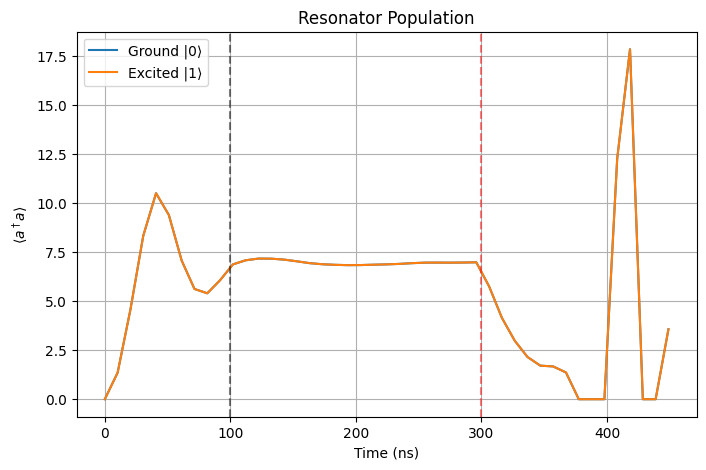

In [3]:
import numpy as np
import matplotlib.pyplot as plt

t = np.asarray(simulation.tsave[:45])
#t = np.arange(0,600, 20)
n_g = np.asarray(result.ground.resonator_population[:45])
n_e = np.asarray(result.excited.resonator_population[:45])

plt.figure(figsize=(8, 5))
plt.plot(t, n_g, label="Ground |0⟩")
plt.plot(t, n_e, label="Excited |1⟩")

plt.axvline(100, color="k", linestyle="--", alpha=0.5)
plt.axvline(300, color="r", linestyle="--", alpha=0.5)

plt.xlabel("Time (ns)")
plt.ylabel(r"$\langle a^\dagger a\rangle$")
plt.title("Resonator Population")
plt.grid(True)
plt.legend()
plt.show()

In [4]:
from pathlib import Path

p = Path("device_parameter.json").resolve()
print(p)

/Users/qumacminim4-c/CR_gate_and_Fluxonium/Fluxonium_sims/device_parameter.json


In [5]:
from pathlib import Path

p = Path("/Users/qumacminim4-c/CR_gate_and_Fluxonium/Fluxonium_sims/device_parameter.json")

print(p.exists())
print(p.stat().st_size)

True
22443


In [ ]:
test_example_readout_runs()

print("Test passed!")

t=Traced<~float32[]>with<DynamicJaxprTrace>, amp=Traced<~float32[]>with<DynamicJaxprTrace>
t=Traced<~float32[]>with<DynamicJaxprTrace>, amp=Traced<~float32[]>with<DynamicJaxprTrace>
t=Traced<~float32[]>with<DynamicJaxprTrace>, amp=Traced<~float32[]>with<DynamicJaxprTrace>
t=Traced<~float32[]>with<DynamicJaxprTrace>, amp=Traced<~float32[]>with<DynamicJaxprTrace>
t=Traced<~float32[]>with<DynamicJaxprTrace>, amp=Traced<~float32[]>with<DynamicJaxprTrace>
t=Traced<~float32[]>with<DynamicJaxprTrace>, amp=Traced<~float32[]>with<DynamicJaxprTrace>
t=Traced<~float32[]>with<DynamicJaxprTrace>, amp=Traced<~float32[]>with<DynamicJaxprTrace>
t=Traced<float32[]>with<DynamicJaxprTrace>, amp=Traced<~float32[]>with<DynamicJaxprTrace>
t=Traced<float32[]>with<DynamicJaxprTrace>, amp=Traced<~float32[]>with<DynamicJaxprTrace>
t=Traced<float32[]>with<DynamicJaxprTrace>, amp=Traced<~float32[]>with<DynamicJaxprTrace>


/Users/qumacminim4-c/CR_gate_and_Fluxonium/Fluxonium_sims/hamiltonian.py:34: UserWarning: A sparse qarray has been converted to dense layout due to element-wise addition with a dense qarray.
  "h_static": h_resonator + h_fluxonium + params.g * drive_op @ n,
/Users/qumacminim4-c/CR_gate_and_Fluxonium/Fluxonium_sims/hamiltonian.py:82: UserWarning: A sparse qarray has been converted to dense layout due to element-wise addition with a dense qarray.
  h_static = h_res + ops["h_fluxonium"] + params.g*(-1j) * (ops["a"]@ ops["n_plus"] - ops["a"].dag()@ ops["n_minus"])  # The static part of the Hamiltonian in the rotating frame includes the resonator Hamiltonian, the fluxonium Hamiltonian, and the coupling term between the drive and the charge operator of the fluxonium. This static Hamiltonian captures the essential physics of the system in the rotating frame, and serves as the baseline for adding the time-dependent drive modulation.


In [ ]:
from __future__ import annotations

import jax.numpy as jnp
import numpy as np
import dynamiqs as dq

from parameters import DeviceParameters, PulseParameters


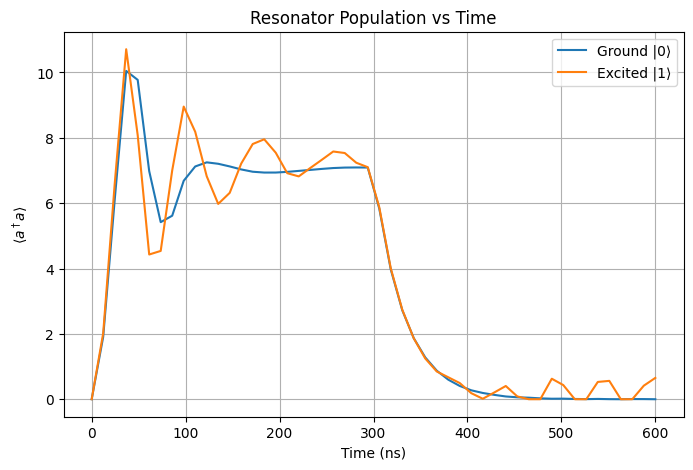

In [ ]:
import matplotlib.pyplot as plt

# Time axis
t = simulation.tsave

# Ground-state trajectory
n_g = result.ground.resonator_population

# Excited-state trajectory
n_e = result.excited.resonator_population

plt.figure(figsize=(8, 5))

plt.plot(t, n_g, label="Ground |0⟩")
plt.plot(t, n_e, label="Excited |1⟩")

plt.xlabel("Time (ns)")
plt.ylabel(r"$\langle a^\dagger a\rangle$")
plt.title("Resonator Population vs Time")
plt.grid(True)
plt.legend()

plt.show()